In [1]:
import pandas as pd

In [3]:
stressLvlDf = pd.read_csv("../data/raw/StressLevelDataset.csv")

In [4]:
stressLvlDf.head(5)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [5]:
feature_cols = [c for c in stressLvlDf.columns if c != "stress_level"]  

outlier_summary = {}

for col in feature_cols:
    Q1 = stressLvlDf[col].quantile(0.25)
    Q3 = stressLvlDf[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = stressLvlDf[(stressLvlDf[col] < lower) | (stressLvlDf[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_counts = pd.Series(outlier_summary).sort_values(ascending=False)
print(outlier_counts)

noise_level                     173
study_load                      165
living_conditions                62
anxiety_level                     0
basic_needs                       0
extracurricular_activities        0
peer_pressure                     0
social_support                    0
future_career_concerns            0
teacher_student_relationship      0
academic_performance              0
safety                            0
self_esteem                       0
breathing_problem                 0
sleep_quality                     0
blood_pressure                    0
headache                          0
depression                        0
mental_health_history             0
bullying                          0
dtype: int64


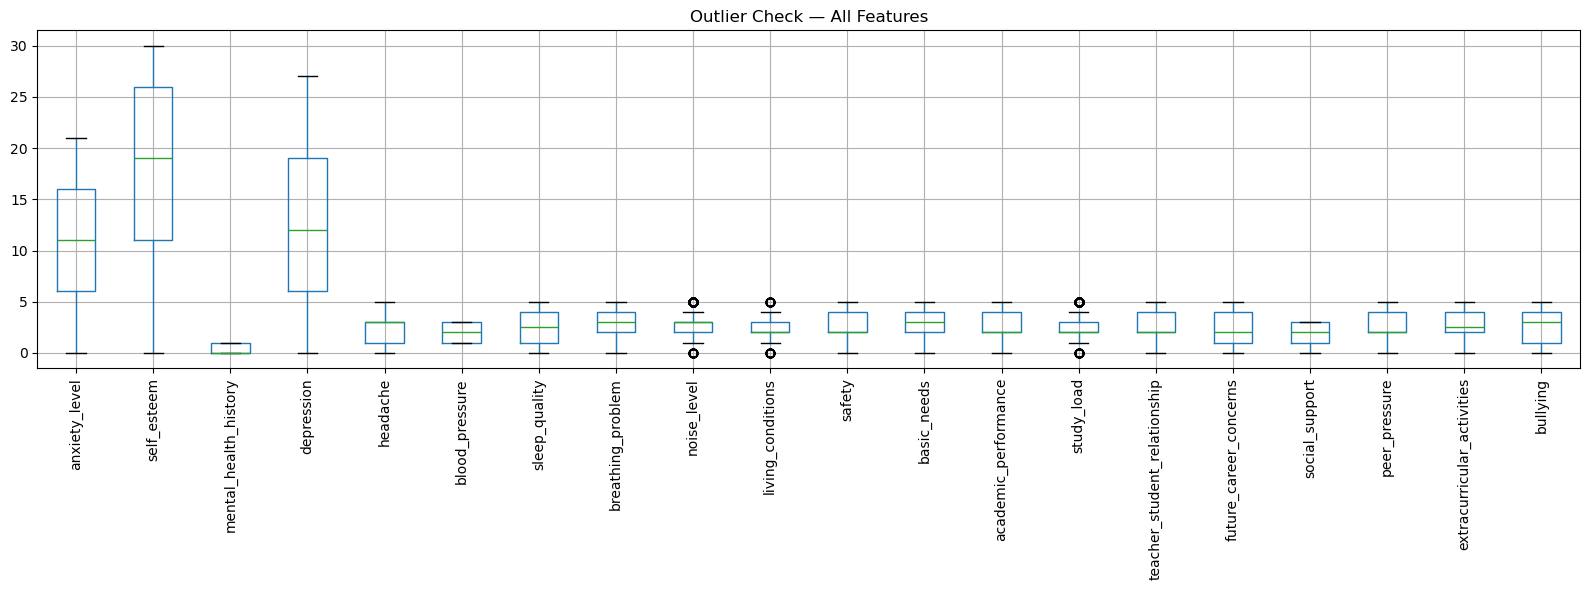

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 6))
stressLvlDf[feature_cols].boxplot(ax=ax, rot=90)
plt.title("Outlier Check — All Features")
plt.tight_layout()
plt.show()

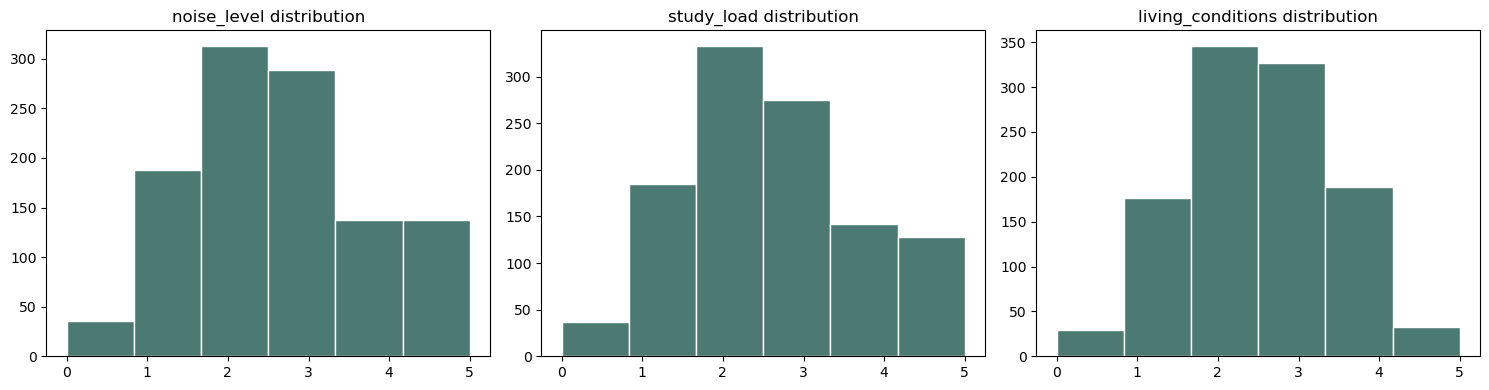

In [7]:
import matplotlib.pyplot as plt

flagged = ["noise_level", "study_load", "living_conditions"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(flagged):
    axes[i].hist(stressLvlDf[col], bins=6, color='#4C7A73', edgecolor='white')
    axes[i].set_title(f"{col} distribution")
plt.tight_layout()
plt.show()

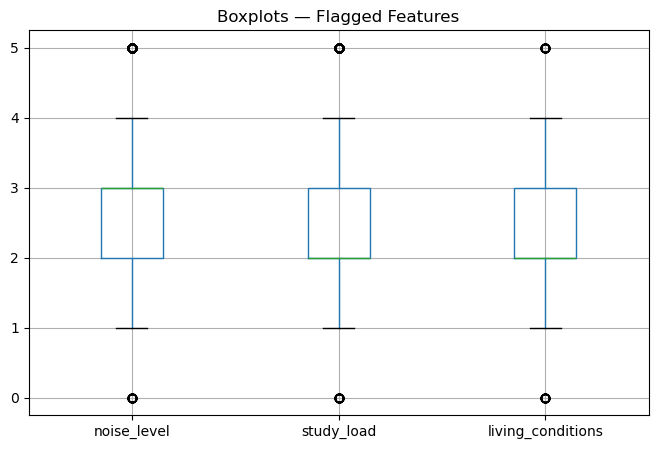

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
stressLvlDf[flagged].boxplot(ax=ax)
plt.title("Boxplots — Flagged Features")
plt.show()

In [ ]:
#No possible outliers found move on to data scaling